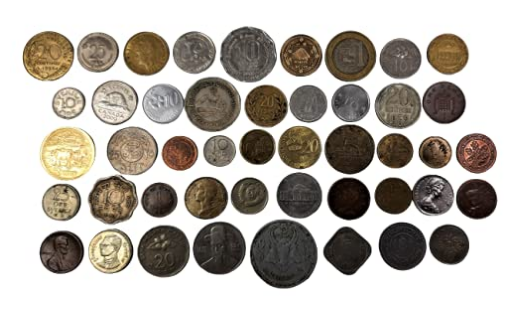

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

coins = cv2.imread('data/coin.jpg')
coins = cv2.cvtColor(coins, cv2.COLOR_BGR2RGB)

plt.imshow(coins)
plt.axis('off')
plt.show()

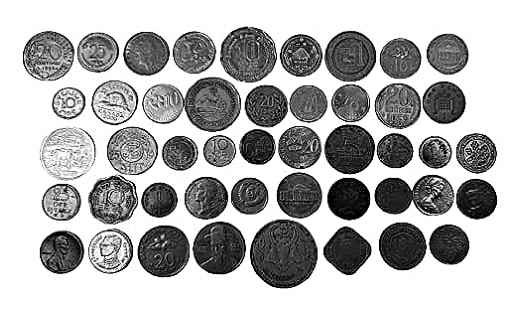

In [2]:
gray_coins = cv2.cvtColor(coins, cv2.COLOR_RGB2GRAY)

sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened_coins = cv2.filter2D(gray_coins, -1, sharpen_kernel)

plt.imshow(sharpened_coins, cmap='gray')
plt.axis('off')
plt.show()

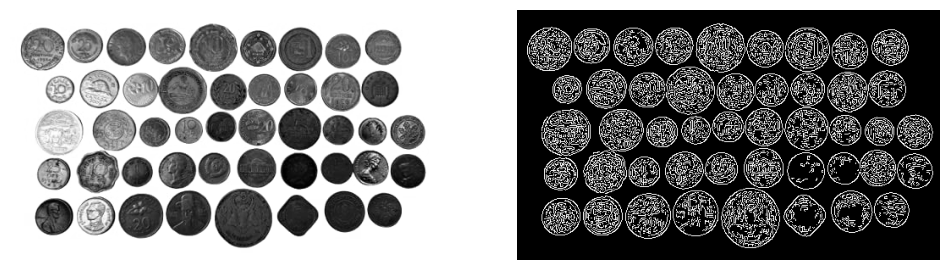

In [11]:
edges = cv2.Canny(sharpened_coins, 100, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(gray_coins, cmap='gray')
ax2.imshow(edges, cmap='gray')
ax1.axis('off')
ax2.axis('off')
plt.show()

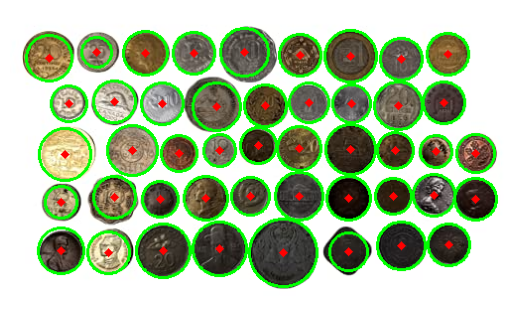

In [55]:
circles = cv2.HoughCircles(
    gray_coins,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=30,
    param1=50,
    param2=40,
    minRadius=15,
    maxRadius=35
)

circle_img = coins.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        center = (circle[0], circle[1])
        radius = circle[2]
        cv2.circle(circle_img, center, radius, (0, 255, 0), 2)
        cv2.circle(circle_img, center, 2, (255, 0, 0), 3)

plt.imshow(circle_img)
plt.axis('off')
plt.show()